# Ti64 Statistical Modelling
## Plotting Stress-strain Curves from Literature
### Rory Atlasi Barker, Guy Bowker

This notebook can be used to filter stress-strain curves for Ti64 hot compression experiments from literature.
Change the temperature, microstructure, strain rate, or other options in the example cells at the bottom to plot the corresponding curves for those conditions.
Functions can be found next to this notebook in `flow_curve_utils.py`.


To add data, simply create a new file in the `Flow_curves/` directory in this repository named after the paper authors as shown containing any figures as `.png`s and the data as `.csv` files.
Then, add the papers metadata and relative filepath to the `flow_curves.yaml` file.

Import relevant libraries:

In [1]:

import numpy as np
import os
import pickle
import sys
import yaml
from yaml.loader import FullLoader
from yaml.loader import SafeLoader

path = os.path.abspath("Flow_curves/")
sys.path.append(path)
from flow_curve_utils import load_yml
from flow_curve_utils import sort_curve
from flow_curve_utils import curve_filter
from flow_curve_utils import flow_curve_plotter

%matplotlib inline

Load `flow_curves.yml` file,
reading in data and metadata show all:

In [2]:

# define alloy which you want curve data for
alloy = 'Ti-6Al-4V'

# load metadata from yml file
database = load_yml(alloy)



Experiments: 
None

Papers: 
dict_keys(['Miller_1999', 'Guo_2019', 'Gao_2014', 'Semiatin_1999', 'Momeni_2010', 'Quan_2016', 'Park_2014', 'Jha_2019', 'Cai_2010', 'Jedrasiak_2022'])


## Filter the data

Filter flow curve data by deformation parameters

In [3]:

# Define desired parameters:
parameters = {                                  # USER OPTIONS GUIDE
              'sample_diameter_mm' : 'any',     # float in mm
              'sample_length_mm' : 'any',       # float in mm
              'microstructure_type' : 'any',    # 'lamellar' or 'equiaxed' or 'any' as str

              'load' : "compressive",           # 'compressive' or 'tensile' or 'any' as str
              'Strain_rate_s-1' : 0.1,          # float unitless

              'Temperature_C' : 900,            # float in C
              'In_situ_heating' : 'any',        # 'induction', 'gleeble' or 'any' as str
    
              'exclusions' : ['Miller_1999']    # dataset keys to exclude (empty if none)
             }


# Filter beta approach curve data by def params:
filtered_database = curve_filter(database, parameters);


Chosen T:900, SR:0.1

Miller_1999 IN EXCLUSIONS LIST.
Including Guo_2019 load:compressive T:900 Strain rate:0.1
Including Gao_2014 load:compressive T:900 Strain rate:0.1
Including Semiatin_1999 load:compressive T:900 Strain rate:0.1
Including Momeni_2010 load:compressive T:900 Strain rate:0.1
Including Quan_2016 load:compressive T:900 Strain rate:0.1
Including Park_2014 load:compressive T:900 Strain rate:0.1
Including Park_2014 load:compressive T:900 Strain rate:0.1
Including Cai_2010 load:compressive T:900 Strain rate:0.1


## Plot the data

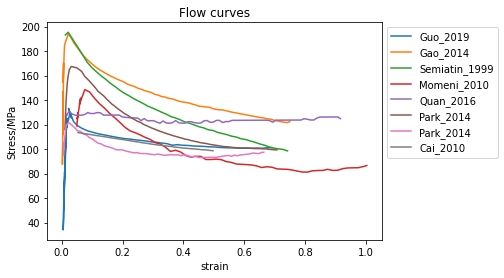

In [4]:
flow_curve_plotter(filtered_database)

## Save database or filtered database as .pkl file
This allows easy import of the dict containing metadata and data into any python code to compare data to other sources

In [5]:

# pickle.dump(database, open('stress_strain_data.pkl', 'wb'))

# pickle.dump(filtered_database, open('stress_strain_data.pkl', 'wb'))
